In [1]:
import sys
import uproot
import awkward as ak
import numpy as np
from coffea import nanoevents
import vector
from rich import print
import math
import matplotlib.pyplot as plt
import matplotlib
import mplhep as hep
import hist
from hist import Hist

In [2]:
sys.path.insert(0, "../workflows/")

In [3]:
matplotlib.rcParams.update({"figure.max_open_warning": 0})
hep.style.use(hep.style.CMS)

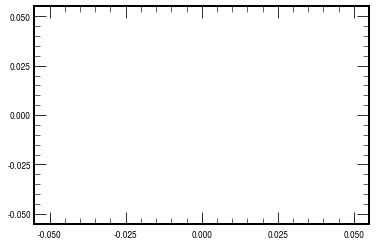

In [4]:
plt.plot()
hep.style.use(hep.style.CMS)

In [5]:
np.set_printoptions(precision=2)

In [6]:
vector.register_awkward()

## Process files
NOTE: These files are just the merged NANOAOD files for `GluGluToSUEP_T32p00_TuneCP5_13TeV_pythia8`

In [7]:
file_2016APV = nanoevents.NanoEventsFactory.from_root(
    "~/nobackup/nano_2016APV.root",
    schemaclass=nanoevents.NanoAODSchema,
)
file_2016 = nanoevents.NanoEventsFactory.from_root(
    # merged result of dasgoclient -query="file dataset=/GluGluToSUEP_T32p00_TuneCP5_13TeV_pythia8/RunIISummer20UL16NanoAODv9-106X_mcRun2_asymptotic_v17-v2/NANOAODSIM"
    "~/nobackup/nano_2016.root",
    schemaclass=nanoevents.NanoAODSchema,
)

events_2016APV = file_2016APV.events()
events_2016 = file_2016.events()

All gen models in `GluGluToSUEP_T32p00_TuneCP5_13TeV_pythia8`

In [8]:
print(len(events_2016APV))
print(len(events_2016))

225000

225000

Select gen model of interest

In [9]:
events_2016APV = events_2016APV[
    events_2016APV.GenModel["SUEP_mS125.000_mPhi8.000_T32.000_modeleptonic"]
]
events_2016 = events_2016[
    events_2016.GenModel["SUEP_mS125.000_mPhi8.000_T32.000_modeleptonic"]
]

Only SUEP_mS125.000_mPhi8.000_T32.000_modeleptonic

In [10]:
print(len(events_2016APV))
print(len(events_2016))

26000

27090

Passing the HLT_TripleMu_5_3_3 trigger **large difference in acceptance**

In [11]:
print(ak.sum(events_2016APV.HLT.TripleMu_5_3_3))
print(ak.sum(events_2016.HLT.TripleMu_5_3_3))

21495

9473

Apply the trigger

In [12]:
events_2016APV = events_2016APV[events_2016APV.HLT.TripleMu_5_3_3]
events_2016 = events_2016[events_2016.HLT.TripleMu_5_3_3]

Number of muons **large difference**

In [13]:
print(ak.num(events_2016APV.Muon))
print(ak.num(events_2016.Muon))

[11, 17, 9, 26, 15, 10, 14, 24, 13, 17, ... 20, 10, 17, 23, 30, 8, 15, 14, 22, 20]

[4, 4, 3, 4, 6, 4, 5, 4, 5, 3, 5, 5, 4, 7, ... 5, 7, 5, 4, 4, 4, 6, 4, 4, 4, 4, 5, 3]

Checking the muon pt's (looks okay)

In [14]:
print(events_2016APV.Muon.pt)
print(events_2016.Muon.pt)

[[89.7, 58.6, 44.8, 41.3, 24.3, 23.6, 15.9, ... 10.7, 9.8, 8, 7.66, 6.83, 5.6, 5.07]]

[[50.7, 40.1, 36.1, 5.05], [19.4, 18.5, ... 13.7, 12.6, 11.3], [26.5, 13.1, 8.15]]

Checking number of gen level particles **large difference**

In [15]:
print(ak.sum(events_2016APV.GenPart.pdgId == 999999, axis=-1))
print(ak.sum(events_2016.GenPart.pdgId == 999999, axis=-1))

[8, 11, 12, 15, 12, 10, 11, 13, 10, 13, ... 16, 14, 12, 17, 14, 8, 11, 14, 22, 18]

[2, 2, 3, 2, 2, 2, 3, 2, 2, 3, 3, 3, 2, 2, ... 3, 3, 2, 2, 2, 2, 3, 2, 3, 3, 2, 2, 2]

In [16]:
print(ak.sum(events_2016APV.GenPart.pdgId == 999998, axis=-1))
print(ak.sum(events_2016.GenPart.pdgId == 999998, axis=-1))

[8, 13, 8, 18, 13, 11, 7, 19, 12, 14, 12, ... 19, 11, 12, 20, 16, 6, 12, 13, 21, 20]

[2, 2, 4, 2, 3, 2, 2, 4, 2, 5, 2, 5, 2, 4, ... 3, 4, 2, 1, 3, 3, 4, 3, 2, 4, 2, 2, 2]